# Test simulation for Valentine paper recreation
## Imports

In [89]:
import math

import matplotlib.pyplot as plt
import numpy as np

import meep as mp
from meep import materials


## Transmittance Baseline
### Cell dimensions

In [90]:
resolution = 50  # pixels/μm

dpml = 1.0  # PML thickness
dsub = 6.0  # substrate thickness
dpad = 6.0 # encapsulant total thickness
ppx = 0.60  # pillar period in x
ppy = 0.600 # pillar period in y
ph = 0.440  # pillar height
pr = 0.140 # pillar radius



sz = dpml + dsub + ph + dpad + dpml
sy = ppy
sx = ppx

cell_size = mp.Vector3(sx, 0, sz)
pml_layers = [mp.PML(thickness=dpml, direction=mp.Z)]

### Source Control

In [ ]:
wvl_min = 1  # min wavelength
wvl_max = 1.4  # max wavelength
fmin = 1 / wvl_max  # min frequency
fmax = 1 / wvl_min  # max frequency
fcen = 0.5 * (fmin + fmax)  # center frequency
df = fmax - fmin  # frequency width

src_pt = mp.Vector3(0, 0, 0.5 * sz - 0.5 * dpml - 0.5 * dpad)
sources = [
    mp.Source(
        mp.GaussianSource(fcen, fwidth=df),
        component=mp.Ey,
        center=src_pt,
        size=mp.Vector3(sx, 0, 0),
    )
]

### Simulation setup

In [92]:
k_point = mp.Vector3()

symmetries = [mp.Mirror(mp.X)]

sim = mp.Simulation(
    resolution=resolution,
    cell_size=cell_size,
    boundary_layers=pml_layers,
    k_point=k_point,
    sources=sources,
    symmetries=symmetries,
)

nfreq = 51
mon_pt = mp.Vector3(0, 0, -0.5 * sz + 0.5 * dpml + 0.5 * dsub)
flux_mon = sim.add_flux(
    fcen, df, nfreq, mp.FluxRegion(center=mon_pt, size=mp.Vector3(sx, 0, 0), direction = mp.Z)
)

### Run

In [93]:
sim.run(until_after_sources = 200)

trans_b = mp.get_fluxes(flux_mon)

-----------
Initializing structure...
Halving computational cell along direction x
time for choose_chunkdivision = 0.000277042 s
Working in 3D dimensions.
Computational cell is 0.6 x 0.02 x 14.44 with resolution 50
time for set_epsilon = 0.0134308 s
-----------


FloatProgress(value=0.0, description='0% done ', max=235.0)

run 0 finished at t = 235.0 (23500 timesteps)


## Test setup 

### Cell setup

In [94]:


glass = materials.fused_quartz
pmma = materials.PMMA
silicon = materials.aSi

geometry = [
    mp.Block(
        material=glass,
        size=mp.Vector3(mp.inf, mp.inf, dpml + dsub),
        center=mp.Vector3(0, 0, -0.5 * sz + 0.5 * dpml + 0.5 * dsub),
    ),
    mp.Block(
        material=glass,
        size=mp.Vector3(mp.inf, mp.inf, dpml + dpad + ph),
        center=mp.Vector3(0, 0, 0.5 * sz - 0.5 * (dpml + dpad + ph)),
    ),
    mp.Block(
        material = silicon,
        size = mp.Vector3(2 * pr, 0, ph),
        center = mp.Vector3(0, 0, 0.5 * ph)
    )
]


### Simulation setup

In [95]:
k_point = mp.Vector3()

symmetries = [mp.Mirror(mp.X)]

sim = mp.Simulation(
    resolution=resolution,
    cell_size=cell_size,
    boundary_layers=pml_layers,
    geometry=geometry,
    k_point=k_point,
    sources=sources,
    symmetries=symmetries,
)

mon_pt = mp.Vector3(0, 0, -0.5 * sz + 0.5 * dpml + 0.5 * dsub)
flux_mon = sim.add_flux(
    fcen, df, nfreq, mp.FluxRegion(center=mon_pt, size=mp.Vector3(sx, 0, 0), direction = mp.Z)
)



## running the code

     block, center = (0,0,-3.72)
          size (1e+20,1e+20,7)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
     block, center = (0,0,3.5)
          size (1e+20,1e+20,7.44)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
     block, center = (0,0,0.22)
          size (0.28,0,0.44)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (3.109,3.109,3.109)


<Axes: xlabel='X', ylabel='Z'>

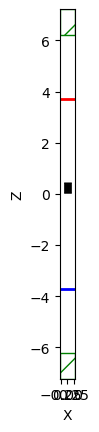

In [96]:
sim.plot2D()

In [97]:
sim.run(until_after_sources=200)

-----------
Initializing structure...
Halving computational cell along direction x
time for choose_chunkdivision = 0.000295877 s
Working in 3D dimensions.
Computational cell is 0.6 x 0.02 x 14.44 with resolution 50
     block, center = (0,0,-3.72)
          size (1e+20,1e+20,7)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
     block, center = (0,0,3.5)
          size (1e+20,1e+20,7.44)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
     block, center = (0,0,0.22)
          size (0.28,0,0.44)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (3.109,3.109,3.109)
time for set_epsilon = 0.0319791 s
lorentzian susceptibility: frequency=3.16976, gamma=1.54858
lorentzian susceptibility: frequency=0.101049, gamma=0
lorentzian susceptibility: frequency=8.60279, gamma=0
lorentzian susceptibility: frequency=14.619, gamma=0
-----------


/Applications/anaconda3/envs/ImgDiff/lib/python3.13/site-packages/meep/simulation.py:1664: RuntimeWarning: Note: your sources include frequencies outside the range of validity of the material models. This is fine as long as you eventually only look at outputs (fluxes, resonant modes, etc.) at valid frequencies.
  warnings.warn(warn_src, RuntimeWarning)
/Applications/anaconda3/envs/ImgDiff/lib/python3.13/site-packages/meep/simulation.py:1668: RuntimeWarning: DFT frequency 0.7142857142857144 is out of material's range of 1.2048192771084338-4.761904761904762
  warnings.warn(
/Applications/anaconda3/envs/ImgDiff/lib/python3.13/site-packages/meep/simulation.py:1668: RuntimeWarning: DFT frequency 1.0 is out of material's range of 1.2048192771084338-4.761904761904762
  warnings.warn(


FloatProgress(value=0.0, description='0% done ', max=235.0)

Meep progress: 105.4/235.0 = 44.9% done in 4.0s, 4.9s to go
on time step 10542 (time=105.42), 0.000379436 s/step
Meep progress: 215.05/235.0 = 91.5% done in 8.0s, 0.7s to go
on time step 21508 (time=215.08), 0.000364788 s/step
run 0 finished at t = 235.0 (23500 timesteps)


In [98]:
tran_new = mp.get_fluxes(flux_mon)

In [99]:
flux_freqs = mp.get_flux_freqs(flux_mon)
wl = []
Ts = []
for i in range(nfreq):
    wl = np.append(wl, 1/flux_freqs[i])
    Ts = np.append(Ts,tran_new[i]/trans_b[i])

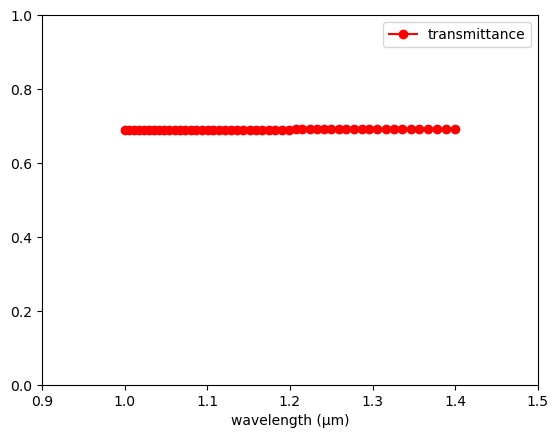

In [100]:
plt.figure()
plt.plot(wl,Ts,'ro-',label='transmittance')
plt.axis([0.9, 1.5, 0, 1])
plt.xlabel("wavelength (μm)")
plt.legend(loc="upper right")
plt.show()

### plotting fields

In [101]:
sim = mp.Simulation(
    resolution=resolution,
    cell_size=cell_size,
    boundary_layers=pml_layers,
    geometry=geometry,
    k_point=k_point,
    sources= [mp.Source(mp.ContinuousSource(frequency = 1.2),
                        component = mp.Ey, 
                        center = mp.Vector3(0, 0, 0.5 * sz - 0.5 * dpml - 0.5 * dpad))],
    symmetries=symmetries
)

mon_pt = mp.Vector3(0, 0, -0.5 * sz + 0.5 * dpml + 0.5 * dsub)
flux_mon = sim.add_flux(
    fcen, df, nfreq, mp.FluxRegion(center=mon_pt, size=mp.Vector3(sx, 0, 0), direction = mp.Z)
)

sim.run(until = 200)

-----------
Initializing structure...
Halving computational cell along direction x
time for choose_chunkdivision = 0.000962019 s
Working in 3D dimensions.
Computational cell is 0.6 x 0.02 x 14.44 with resolution 50
     block, center = (0,0,-3.72)
          size (1e+20,1e+20,7)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
     block, center = (0,0,3.5)
          size (1e+20,1e+20,7.44)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
     block, center = (0,0,0.22)
          size (0.28,0,0.44)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (3.109,3.109,3.109)
time for set_epsilon = 0.042134 s
lorentzian susceptibility: frequency=3.16976, gamma=1.54858
lorentzian susceptibility: frequency=0.101049, gamma=0
lorentzian susceptibility: frequency=8.60279, gamma=0
lorentzian susceptibility: frequency=14.619, gamma=0
-----------


FloatProgress(value=0.0, description='0% done ', max=200.0)

Meep progress: 97.66/200.0 = 48.8% done in 4.0s, 4.2s to go
on time step 9770 (time=97.7), 0.000409424 s/step
Meep progress: 198.51/200.0 = 99.3% done in 8.0s, 0.1s to go
on time step 19856 (time=198.56), 0.000396606 s/step
run 0 finished at t = 200.0 (20000 timesteps)


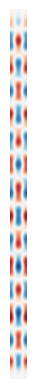

In [102]:
ez_data = sim.get_array(center=mp.Vector3(), size=cell_size, component=mp.Ey)
plt.figure()
plt.imshow(eps_data.transpose(), interpolation='spline36', cmap='binary')
plt.imshow(ez_data.transpose(), interpolation='spline36', cmap='RdBu', alpha=0.9)
plt.axis('off')
plt.show()